# Mini-Project: Predicting Heart Disease Using Logistic Regression

**Goal:** Use the *Heart Disease UCI* dataset to predict whether a patient has heart disease based on medical attributes.

**Workflow**
1. **Data Preparation** – Exploratory Data Analysis (EDA), handle missing values, encode categorical variables, scale features.
2. **Model Training** – Split into train/test sets and train a Logistic Regression model.
3. **Model Evaluation** – Accuracy, Precision, Recall, F1-score, confusion matrix, classification report and ROC curve.

## 1. Imports & Setup

In [34]:
# --- Core data-handling and plotting libraries ---
import numpy as np                 # numerical operations / arrays
import pandas as pd                # tabular data (DataFrames)
import matplotlib.pyplot as plt    # base plotting library
import seaborn as sns              # high-level statistical plots built on matplotlib

# --- scikit-learn: model selection, preprocessing, model, metrics ---
from sklearn.model_selection import train_test_split   # split data into train/test
from sklearn.compose import ColumnTransformer          # apply different transforms per column group
from sklearn.pipeline import Pipeline                  # chain preprocessing + model into one object
from sklearn.impute import SimpleImputer               # fill in missing values
from sklearn.preprocessing import StandardScaler, OneHotEncoder  # scale numerics / encode categories
from sklearn.linear_model import LogisticRegression    # the classification model we will train
from sklearn.metrics import (                          # evaluation metrics and helpers
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report,
    roc_curve, roc_auc_score,
)

# --- Global display / reproducibility settings ---
sns.set_theme(style="whitegrid")          # consistent, readable plot style
pd.set_option("display.max_columns", None)  # show every column when printing DataFrames
RANDOM_STATE = 42                          # fixed seed so results are reproducible across runs

## 2. Load the Data

In [35]:
# Read the CSV file into a pandas DataFrame
df = pd.read_csv("heart_disease_uci.csv")

# Report the size: (rows = patients, columns = attributes)
print(f"Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns")

# Preview the first 5 rows to see the raw structure of the data
df.head()

Dataset shape: 920 rows × 16 columns


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


## 3. Exploratory Data Analysis (EDA)

**Column reference**

| Column | Meaning |
|---|---|
| `age` | Age in years |
| `sex` | Male / Female |
| `dataset` | Source hospital (Cleveland, Hungary, …) |
| `cp` | Chest pain type |
| `trestbps` | Resting blood pressure (mm Hg) |
| `chol` | Serum cholesterol (mg/dl) |
| `fbs` | Fasting blood sugar > 120 mg/dl |
| `restecg` | Resting ECG result |
| `thalch` | Maximum heart rate achieved |
| `exang` | Exercise-induced angina |
| `oldpeak` | ST depression induced by exercise |
| `slope` | Slope of peak exercise ST segment |
| `ca` | Number of major vessels (0–3) colored by fluoroscopy |
| `thal` | Thalassemia result |
| `num` | **Target** – diagnosis (0 = no disease, 1–4 = disease severity) |

In [36]:
# Column data types and non-null counts.
# This quickly reveals which columns have missing values and whether
# a column is numeric (int/float) or categorical (object/str).
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    str    
 3   dataset   920 non-null    str    
 4   cp        920 non-null    str    
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    str    
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    str    
 13  ca        309 non-null    float64
 14  thal      434 non-null    str    
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(2), str(6)
memory usage: 115.1+ KB


In [9]:
# Summary statistics for ALL columns (include="all").
# - Numeric columns show mean, std, min, quartiles, max.
# - Categorical columns show count, number of unique values, most frequent value.
# .T transposes the table so each feature is a row (easier to read).
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,920.0,NaN,NaN,NaN,460.5,265.725422,1.0,230.75,460.5,690.25,920.0
age,920.0,NaN,NaN,NaN,53.51087,9.424685,28.0,47.0,54.0,60.0,77.0
sex,920,2,Male,726,NaN,NaN,NaN,NaN,NaN,NaN,NaN
dataset,920,4,Cleveland,304,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cp,920,4,asymptomatic,496,NaN,NaN,NaN,NaN,NaN,NaN,NaN
trestbps,861.0,NaN,NaN,NaN,132.132404,19.06607,0.0,120.0,130.0,140.0,200.0
chol,890.0,NaN,NaN,NaN,199.130337,110.78081,0.0,175.0,223.0,268.0,603.0
fbs,830,2,False,692,NaN,NaN,NaN,NaN,NaN,NaN,NaN
restecg,918,3,normal,551,NaN,NaN,NaN,NaN,NaN,NaN,NaN
thalch,865.0,NaN,NaN,NaN,137.545665,25.926276,60.0,120.0,140.0,157.0,202.0


In [10]:
# --- Quantify missing values per column ---
missing = df.isnull().sum()                       # count of NaNs in each column
missing_pct = (missing / len(df) * 100).round(1)  # same, expressed as a percentage

# Combine count and percentage into a single readable table
missing_table = pd.DataFrame({"missing": missing, "percent": missing_pct})

# Keep only columns that actually have missing values, sorted worst-first
missing_table = missing_table[missing_table["missing"] > 0].sort_values("missing", ascending=False)
missing_table

,missing,percent
ca,611,66.4
thal,486,52.8
slope,309,33.6
fbs,90,9.8
oldpeak,62,6.7
trestbps,59,6.4
thalch,55,6.0
exang,55,6.0
chol,30,3.3
restecg,2,0.2


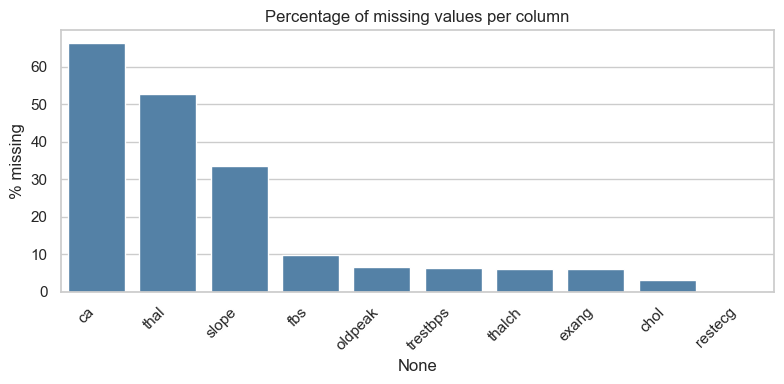

In [11]:
# Visualize the missing-value percentages as a bar chart.
# This makes it obvious that `ca`, `thal` and `slope` are the biggest gaps.
plt.figure(figsize=(8, 4))
sns.barplot(x=missing_table.index, y=missing_table["percent"], color="steelblue")
plt.title("Percentage of missing values per column")
plt.ylabel("% missing")
plt.xticks(rotation=45, ha="right")   # rotate labels so they don't overlap
plt.tight_layout()                    # prevent labels from being clipped
plt.show()

### Target variable

The raw target `num` ranges from 0 to 4 (severity of disease). For this binary classification task we map it to:
- **0** → no heart disease
- **1** → heart disease present (any of 1–4)

In [12]:
# The raw target `num` has 5 levels (0 = healthy, 1-4 = increasing severity).
print("Original `num` distribution:")
print(df["num"].value_counts().sort_index())

# Convert to a BINARY target: 0 = no disease, 1 = disease present (any severity > 0).
# (df["num"] > 0) gives True/False; .astype(int) turns it into 1/0.
df["target"] = (df["num"] > 0).astype(int)

# Check the balance of the two classes
print("\nBinary target distribution:")
print(df["target"].value_counts())
print(f"\nPositive (disease) rate: {df['target'].mean():.1%}")  # share of patients with disease

Original `num` distribution:
num
0    411
1    265
2    109
3    107
4     28
Name: count, dtype: int64

Binary target distribution:
target
1    509
0    411
Name: count, dtype: int64

Positive (disease) rate: 55.3%


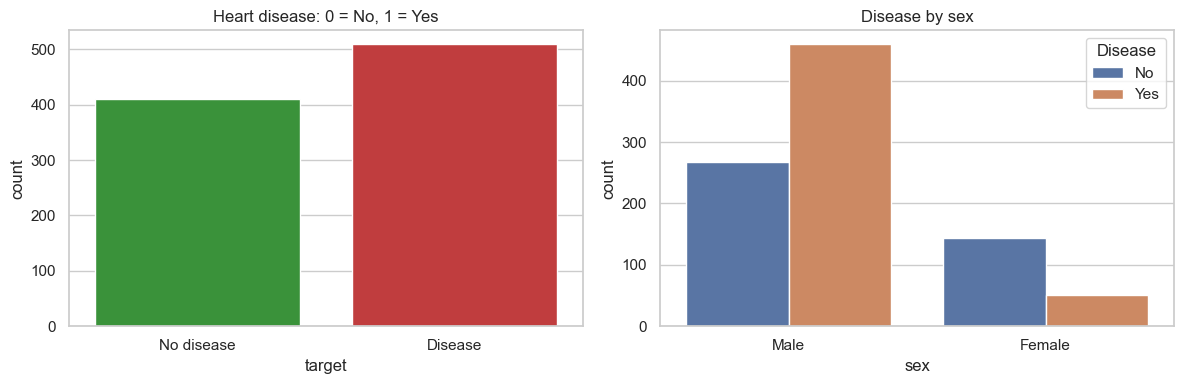

In [26]:
# Two side-by-side count plots to understand class balance and a key relationship.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: overall count of disease vs. no disease (is the dataset balanced?)
# In newer seaborn, a custom palette must be tied to `hue`; legend=False hides the redundant legend.
sns.countplot(x="target", hue="target", data=df, ax=axes[0],
              palette=["#2ca02c", "#d62728"], legend=False)
axes[0].set_title("Heart disease: 0 = No, 1 = Yes")
axes[0].set_xticks([0, 1])                            # fix tick positions first...
axes[0].set_xticklabels(["No disease", "Disease"])    # ...then label them (avoids the warning)

# Right: disease counts broken down by sex (do men/women differ?)
sns.countplot(x="sex", hue="target", data=df, ax=axes[1])
axes[1].set_title("Disease by sex")
axes[1].legend(title="Disease", labels=["No", "Yes"])

plt.tight_layout()
plt.show()

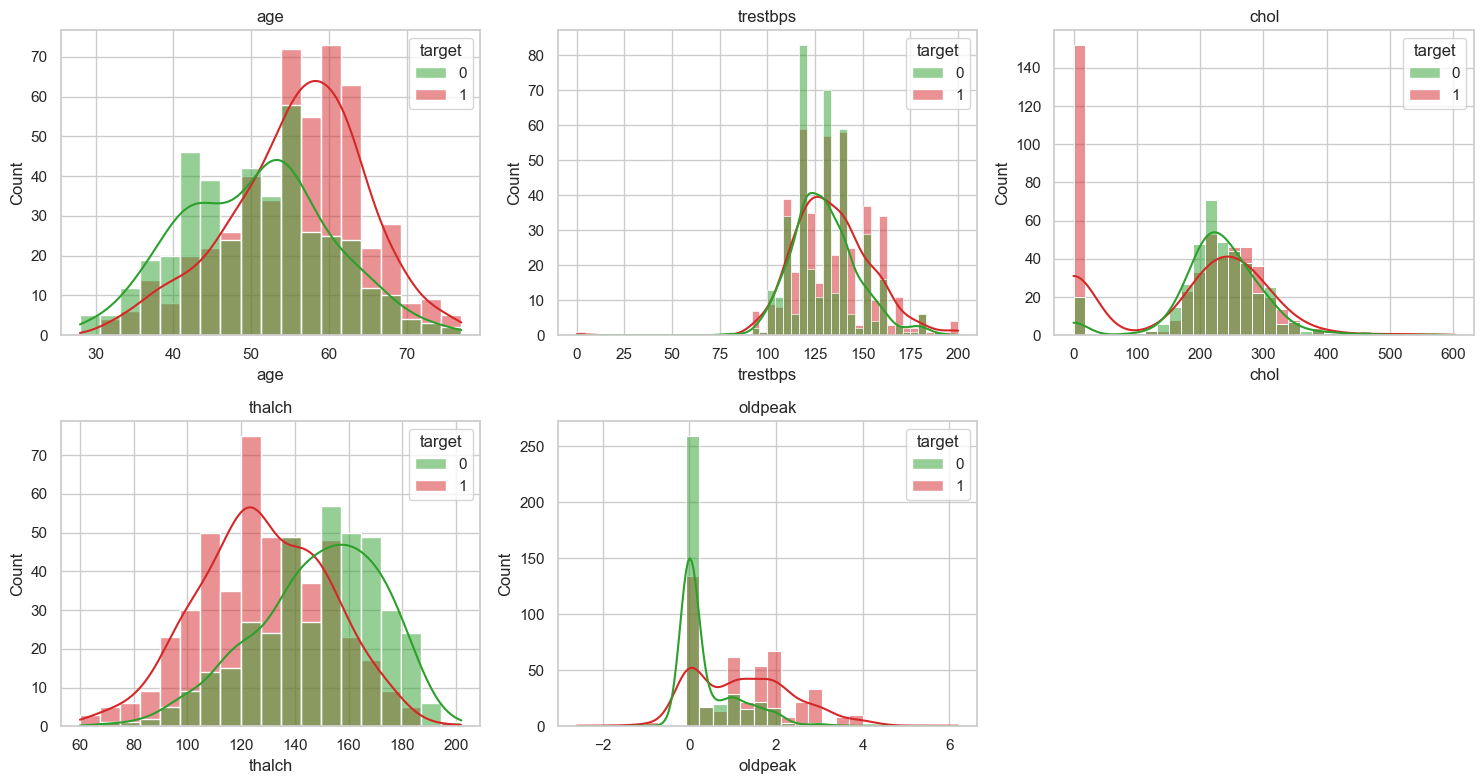

In [14]:
# Compare the distribution of each key numeric feature between the two classes.
# Overlapping histograms (green = no disease, red = disease) show which features
# separate the classes well (e.g. thalch and oldpeak tend to differ noticeably).
numeric_features = ["age", "trestbps", "chol", "thalch", "oldpeak"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))   # 2x3 grid (6 slots for 5 features)
for ax, col in zip(axes.flat, numeric_features):
    sns.histplot(data=df, x=col, hue="target", kde=True, ax=ax,
                 palette=["#2ca02c", "#d62728"])  # kde=True overlays a smooth density curve
    ax.set_title(col)

axes.flat[-1].axis("off")   # hide the unused 6th subplot
plt.tight_layout()
plt.show()

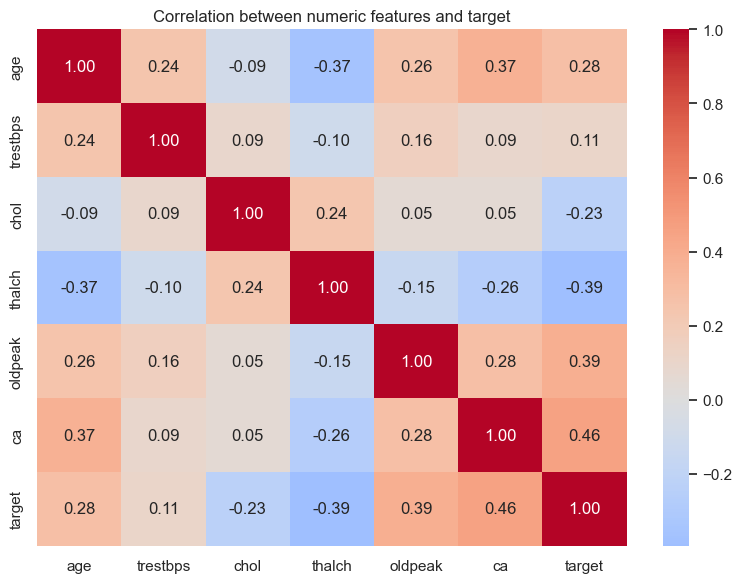

In [15]:
# Correlation heatmap: how strongly numeric features relate to each other and to the target.
# Values range from -1 (inverse) to +1 (direct). The `target` row/column shows which
# numeric features are most linearly associated with heart disease.
plt.figure(figsize=(8, 6))
corr = df[numeric_features + ["ca", "target"]].corr()   # Pearson correlation matrix
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)  # annotate cells, center colormap at 0
plt.title("Correlation between numeric features and target")
plt.tight_layout()
plt.show()

# Correlation Heatmap Interpretation

The heatmap suggests that **heart disease is a multifactorial condition**. No single measurement is sufficient for prediction; instead, a combination of vessel blockage (`ca`), exercise-induced abnormalities (`oldpeak`), heart-rate performance (`thalch`), and age provides the strongest predictive signal.

## 4. Preprocessing

We will:
1. Drop the non-predictive `id` column and the original `num` (replaced by `target`). We also drop `dataset` (it identifies the source hospital, not a medical attribute).
2. Separate **numeric** and **categorical** features.
3. Build a `ColumnTransformer` that:
   - imputes missing numeric values with the **median** and scales them with `StandardScaler`;
   - imputes missing categorical values with the **most frequent** value and one-hot encodes them.

Doing this inside a `Pipeline` guarantees the scaler/imputer are fit **only on the training data**, avoiding data leakage.

In [17]:
# --- Separate features (X) from the target (y) ---
# Drop columns that should NOT be model inputs:
#   id      -> just a row identifier, no predictive value
#   num     -> the original target (would leak the answer)
#   target  -> our label, kept separately in y
#   dataset -> the source hospital, not a medical attribute
X = df.drop(columns=["id", "num", "target", "dataset"])
y = df["target"]

# Group the remaining columns by type so each gets the right preprocessing.
# Note: `fbs` and `exang` are True/False booleans stored as objects -> treat as categorical.
numeric_cols = ["age", "trestbps", "chol", "thalch", "oldpeak", "ca"]
categorical_cols = ["sex", "cp", "fbs", "restecg", "exang", "slope", "thal"]

print("Numeric features:", numeric_cols)
print("Categorical features:", categorical_cols)

Numeric features: ['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca']
Categorical features: ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']


In [18]:
# Preprocessing recipe for NUMERIC columns:
#   1) fill missing values with the column median (robust to outliers)
#   2) standardize to mean 0 / std 1 so all features are on a comparable scale
numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

# Preprocessing recipe for CATEGORICAL columns:
#   1) fill missing values with the most frequent category
#   2) one-hot encode into 0/1 dummy columns (handle_unknown="ignore" avoids
#      errors if a category appears in test but not in train)
categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

# Combine both recipes: apply the right one to the right group of columns.
preprocessor = ColumnTransformer([
    ("num", numeric_pipe, numeric_cols),
    ("cat", categorical_pipe, categorical_cols),
])
preprocessor   # display the transformer diagram

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``

## 5. Model Training

We split the data into 80% training and 20% testing, stratifying on the target so both sets keep the same disease ratio.

In [19]:
# Split into 80% training / 20% testing.
#   stratify=y       -> keep the same disease ratio in both sets
#   random_state=... -> reproducible split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f"Training set: {X_train.shape[0]} samples")
print(f"Testing set:  {X_test.shape[0]} samples")

Training set: 736 samples
Testing set:  184 samples


In [20]:
# Build ONE pipeline that first preprocesses the data, then feeds it to the model.
# Bundling them means the exact same transformations are applied automatically at
# prediction time, and the imputer/scaler are fit ONLY on training data (no leakage).
model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
    # max_iter=1000 gives the solver enough iterations to converge
])

# Train the whole pipeline on the training data
model.fit(X_train, y_train)
print("Model trained successfully.")

Model trained successfully.


## 6. Model Evaluation

In [21]:
# Make predictions on the unseen test set
y_pred = model.predict(X_test)                  # hard 0/1 class predictions
y_proba = model.predict_proba(X_test)[:, 1]     # predicted probability of class 1 (disease)

# Compute the core classification metrics:
metrics = {
    "Accuracy":  accuracy_score(y_test, y_pred),   # overall fraction correct
    "Precision": precision_score(y_test, y_pred),  # of predicted-disease, how many truly are
    "Recall":    recall_score(y_test, y_pred),     # of actual-disease, how many we caught
    "F1 score":  f1_score(y_test, y_pred),         # harmonic mean of precision & recall
    "ROC AUC":   roc_auc_score(y_test, y_proba),   # ranking quality across all thresholds
}
for name, value in metrics.items():
    print(f"{name:10s}: {value:.3f}")

Accuracy  : 0.842
Precision : 0.841
Recall    : 0.882
F1 score  : 0.861
ROC AUC   : 0.904


In [22]:
# Per-class precision/recall/F1 plus support (number of samples in each class).
# Gives a more detailed breakdown than the single-number metrics above.
print(classification_report(y_test, y_pred, target_names=["No disease", "Disease"]))

              precision    recall  f1-score   support

  No disease       0.84      0.79      0.82        82
     Disease       0.84      0.88      0.86       102

    accuracy                           0.84       184
   macro avg       0.84      0.84      0.84       184
weighted avg       0.84      0.84      0.84       184



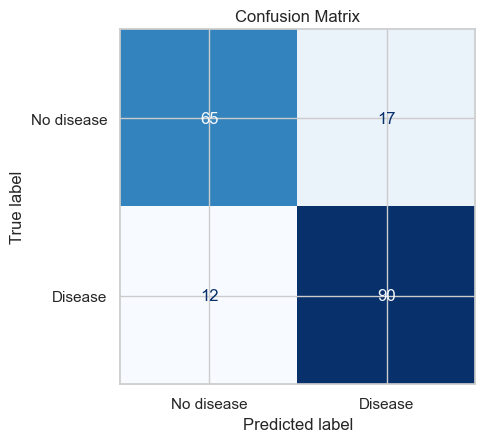

In [23]:
# Confusion matrix: counts of correct vs. incorrect predictions per class.
#   top-left / bottom-right = correct;  off-diagonal = errors
#   (top-right = false positives, bottom-left = false negatives / missed patients)
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No disease", "Disease"])

fig, ax = plt.subplots(figsize=(5, 5))
disp.plot(cmap="Blues", ax=ax, colorbar=False)
ax.set_title("Confusion Matrix")
plt.tight_layout()
plt.show()

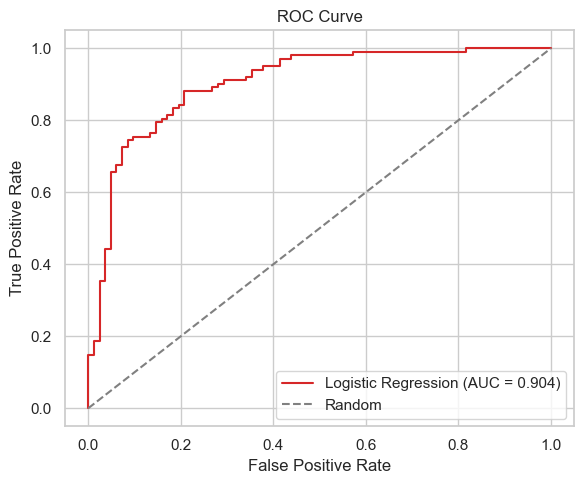

In [24]:
# ROC curve: true-positive rate vs. false-positive rate across every threshold.
# A curve hugging the top-left corner = a strong classifier; the dashed diagonal
# represents random guessing. AUC (area under the curve) summarizes this in one number.
fpr, tpr, _ = roc_curve(y_test, y_proba)   # points of the curve (3rd value = thresholds, unused)
auc = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {auc:.3f})", color="#d62728")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random")  # baseline
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

### Which features drive the prediction?

We can inspect the logistic regression coefficients. Positive coefficients push the prediction toward *disease*, negative ones toward *no disease*.

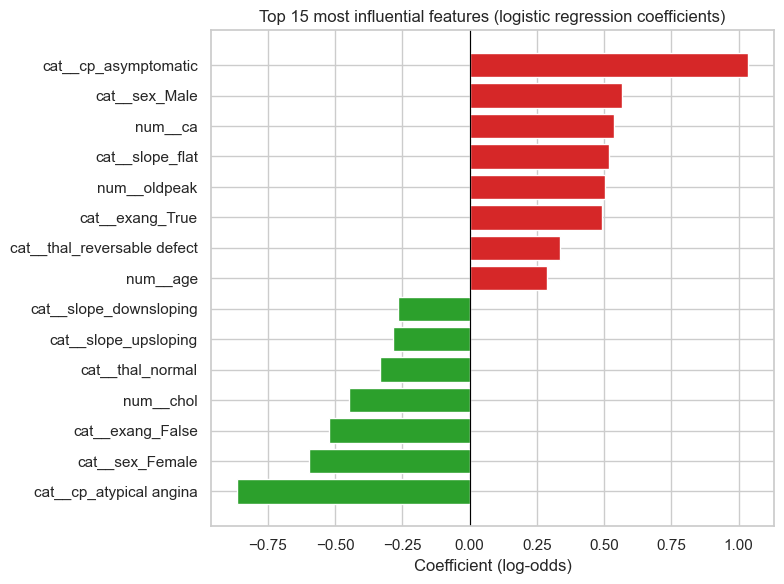

In [25]:
# Extract the learned coefficients to see which features drive the prediction.
# get_feature_names_out() gives the names AFTER one-hot encoding (e.g. "cat__cp_asymptomatic").
feature_names = model.named_steps["preprocessor"].get_feature_names_out()
coefs = model.named_steps["classifier"].coef_[0]   # one coefficient per (encoded) feature

# Build a tidy table and sort by absolute magnitude (strongest influence first)
coef_df = pd.DataFrame({"feature": feature_names, "coefficient": coefs})
coef_df = coef_df.reindex(coef_df["coefficient"].abs().sort_values(ascending=False).index)

# Plot the 15 most influential features as a horizontal bar chart.
# Red bars (positive) push toward "disease"; green bars (negative) push toward "no disease".
plt.figure(figsize=(8, 6))
top = coef_df.head(15).sort_values("coefficient")   # sort for a clean ascending bar layout
colors = ["#d62728" if c > 0 else "#2ca02c" for c in top["coefficient"]]
plt.barh(top["feature"], top["coefficient"], color=colors)
plt.title("Top 15 most influential features (logistic regression coefficients)")
plt.xlabel("Coefficient (log-odds)")
plt.axvline(0, color="black", linewidth=0.8)   # reference line at 0 (no effect)
plt.tight_layout()
plt.show()

## 7. Conclusion

- We loaded the **Heart Disease UCI** dataset (920 patients) and explored it with EDA, finding several columns with missing values (notably `ca`, `thal` and `slope`).
- The multi-class severity target `num` was converted into a **binary target** (disease vs. no disease).
- A scikit-learn **`Pipeline`** handled imputation, scaling and one-hot encoding cleanly, preventing data leakage between train and test sets.
- A **Logistic Regression** model was trained and evaluated using **accuracy, precision, recall, F1-score and ROC AUC**, accompanied by a confusion matrix and a classification report.
- The coefficient plot highlights which medical attributes most strongly influence the prediction.

**Possible improvements:** try regularization tuning (`C`), compare with other models (Random Forest, Gradient Boosting), use cross-validation for more robust metric estimates, and adjust the decision threshold to favor recall — important in a medical screening context where missing a sick patient is costly.